# Tech Challenge - Fase 1
### **Integrantes (Nome Completo - RM):**
Vão preenchendo o de vocês abaixo nessa lista


*   Bianca Domingos dos Santos - RM373748
*   Giovanna Kaori Pavanelli Alicawa - RM370733
*   Guilherme Fernandes da Silva - RM372403
*   Isabele Cristina Felix Santos - RM371797
*   Vitor Varelo de Sousa - RM371925

### 1. Acesso aos dados

In [ ]:
# @title
# BIBLIOTECAS
import kagglehub # Kaggle
import pandas as pd # Manipulação de tabelas, cálculos, etc.
import os # Interação com sistemas operacionais, permite navegar por arquivos, etc.
import duckdb # Manipulação de datasets via SQL

# Acessar o Repositório Kaggle disponibilizado para o Tech Challenge
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("")
# Listar os datasets disponíveis no repositório
datasets = sorted(os.listdir(path))

# Baseado nas descrições no kaggle, criei esse dicionário para nos apoiar no projeto
descricoes = {
    "olist_customers_dataset.csv": "CLIENTE: ID e Localização (Estado, Cidade e ZIP Code)",
    "olist_geolocation_dataset.csv": "LOCALIZAÇÃO: Relação entre Estado, Cidade e ZIP Code x Latitude e Longitude",
    "olist_order_items_dataset.csv": "PEDIDOS: ID do pedido, produto e vendedor, itens e produtos, data, vendedor, preço e frete",
    "olist_order_payments_dataset.csv": "PAGAMENTOS: ID do pedido, tipo de pagamento, parcelas e valor total",
    "olist_order_reviews_dataset.csv": "AVALIAÇÕES: ID do pedido e avaliação, data, nota e comentários",
    "olist_orders_dataset.csv": "PRINCIPAL! Relação Pedido, Cliente e Status com datas de cada etapa",
    "olist_products_dataset.csv": "PRODUTOS: ID do produto, nome, descrição, categoria e medidas",
    "olist_sellers_dataset.csv": "VENDEDORES: ID do vendedor, estado, cidade e ZIP Code",
    "product_category_name_translation.csv": "TRADUÇÕES: Categoria em Inglês e Português",
}

# Printa nome - descrição
i = 0
for nome in datasets:
    print(f"{i}. {nome} - {descricoes[nome]}")
    i=i+1

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.

0. olist_customers_dataset.csv - CLIENTE: ID e Localização (Estado, Cidade e ZIP Code)
1. olist_geolocation_dataset.csv - LOCALIZAÇÃO: Relação entre Estado, Cidade e ZIP Code x Latitude e Longitude
2. olist_order_items_dataset.csv - PEDIDOS: ID do pedido, produto e vendedor, itens e produtos, data, vendedor, preço e frete
3. olist_order_payments_dataset.csv - PAGAMENTOS: ID do pedido, tipo de pagamento, parcelas e valor total
4. olist_order_reviews_dataset.csv - AVALIAÇÕES: ID do pedido e avaliação, data, nota e comentários
5. olist_orders_dataset.csv - PRINCIPAL! Relação Pedido, Cliente e Status com datas de cada etapa
6. olist_products_dataset.csv - PRODUTOS: ID do produto, nome, descrição, categoria e medidas
7. olist_sellers_dataset.csv - VENDEDORES: ID do vendedor, estado, cidade e ZIP Code
8. product_category_name_translation.csv - TRADUÇÕES: Categoria em Inglês e Português


In [ ]:
# @title
# EXEMPLO - 1º dataset do repositório
df = pd.read_csv(f"{path}/{datasets[0]}")
df.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


### 2. Verifica duplicidades nas tabelas que serão usadas

2.1. **PEDIDOS (df_pedidos):** Vamos pegar as informações de produtos, vendedores e ticket médio

In [ ]:
# @title
# Função info do pandas: traz informações relevantes da tabela, como qtd. de linhas e colunas e tipos de dados. permite ver se existem dados faltantes em alguma coluna
df_pedidos = pd.read_csv(f"{path}/{datasets[2]}")
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
# Função describe do pandas: traz estatísticas relevantes das colunas numéricas da tabela, permite identificar possíveis gaps.
# Normalmente precisamos de conhecimento do negócio para conseguir questionar esses dados.
df_pedidos.describe()

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# Por que desvio padrão de order item deu menor que 1 se o mínimo é 1?
# Preço mínimo do pedido de 0.85?
# Podemos ter frete zerado? Teoricamente sim, caso tenham promoções, cupons etc. mas vamos verificar
# Podemos ter frete de 409 reais?

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:
# Função describe + object do pandas: traz estatísticas comuns para colunas textuais da tabela, é menos utilizada mas no discovery é legal usar.
df_pedidos.describe(include="object")

######## DESCOBERTAS ########
# Verificar unique entre ids: order x item x product x seller
# Teoricamente devemos ter no máximo 98.666 pedidos, 32.951 produtos (verificar na tabela PRODUTOS) e 3.095 vendedores (verificar na tabela VENDEDORES)

,order_id,product_id,seller_id,shipping_limit_date
count,112650,112650,112650,112650
unique,98666,32951,3095,93318
top,8272b63d03f5f79c56e9e4120aec44ef,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23
freq,21,527,2033,21


In [ ]:
# Verificando quantidade de duplicatas entre ids: order x item x product x seller
df_pedidos.duplicated(subset=["order_id", "order_item_id", "product_id", "seller_id"]).sum()

np.int64(0)

2.2. **PRINCIPAL (df_principal):** Vamos usar como origem principal e pegar status + datas

In [ ]:
df_principal = pd.read_csv(f"{path}/{datasets[5]}")
df_principal.info()

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# order_approved_at, order_delivered_carrier_date e order_delivered_customer_date com valores nulos
# Verificar se colunas com valores nulos tem relação com a coluna de status

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
# Como só tem colunas textuais, usamos apenas essa função com o include
df_principal.describe(include="object")

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# Aparentemente order_estimated_delivery_date não é um dado confiável, possui poucos unique e alta recorrência na data 2017-12-20 00:00:00

# obs: como order_id e customer_id são unique, não precisamos verificar a relação entre ambas


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [ ]:
# Quantidade de ocorrências por categoria - Status
df_principal["order_status"].value_counts()

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# O que significa e o que fazer com status = unavailable? Tem alta quantidade
# Qual a ordenação correta? created > processing > invoiced > approved > shipped > delivered / canceled

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


2.3. **AVALIAÇÕES (df_avaliacoes):** Vamos usar como origem principal e pegar status + datas

In [ ]:
df_avaliacoes = pd.read_csv(f"{path}/{datasets[4]}")
df_avaliacoes.info()

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# oreview_comment_title e review_comment_message com valores nulos, como não vamos usar acho que não é um problema

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
df_avaliacoes.describe()


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df_avaliacoes.describe(include="object")

######## PONTOS DE ATENÇÃO: Verificar se está correto ########
# Verificar se review_id x order_id é chave única
# review_creation_date parece não ser um dado confiável
# O que fazer com orders com mais de uma review??

,review_id,order_id,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,11568,40977,99224,99224
unique,98410,98673,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,03c939fd7fd3b38f8485a0f95798f1f6,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,423,230,463,4


In [ ]:
df_avaliacoes.duplicated(subset=["review_id", "order_id"]).sum()
# OK - Chave única

np.int64(0)

2.4. **NOMENCLATURAS + REGIÃO:** apenas para pegar depara de ids e região

In [ ]:
df_produtos = pd.read_csv(f"{path}/{datasets[6]}")
df_clientes = pd.read_csv(f"{path}/{datasets[0]}")
df_vendedores = pd.read_csv(f"{path}/{datasets[7]}")

### 3. Criar dataset único para manipulação - cruza tabelas principal, pedidos e avaliações

In [ ]:
produtos_final = duckdb.query("""
    SELECT DISTINCT  prnp.order_id                                                              as id_pedido
                    ,prnp.customer_id                                                           as id_cliente
                    ,pdd.seller_id                                                              as id_vendedor
                    ,pdd.product_id                                                             as id_produto

                    ,prod.product_category_name                                                 as categoria_produto

                    ,pdd.price                                                                  as valor_produto
                    ,pdd.freight_value                                                          as valor_frete

                    ,vend.seller_state                                                          as estado_vendedor
                    ,cli.customer_state                                                         as estado_cliente

                    ,prnp.order_status                                                          as status_pedido
                    ,strftime(CAST(prnp.order_purchase_timestamp  AS TIMESTAMP), '%Y%m%d')      as dt_pedido
                    ,strftime(CAST(prnp.order_delivered_carrier_date  AS TIMESTAMP), '%Y%m%d')  as dt_enviado
                    ,strftime(CAST(prnp.order_delivered_customer_date  AS TIMESTAMP), '%Y%m%d') as dt_entrega

                    -- Ocorrência de +1 avaliação por pedido
                    ,count(aval.review_score)                                                   as qtd_avaliacao
                    ,max(aval.review_score)                                                     as max_avaliacao
                    ,min(aval.review_score)                                                     as min_avaliacao
                    ,cast(avg(aval.review_score) as int)                                        as avg_avaliacao

    FROM df_principal as prnp
    LEFT JOIN df_pedidos as pdd
    ON prnp.order_id = pdd.order_id

    LEFT JOIN df_avaliacoes as aval
    ON prnp.order_id = aval.order_id

    LEFT JOIN df_produtos as prod
    ON pdd.product_id = prod.product_id

    LEFT JOIN df_clientes as cli
    ON prnp.customer_id = cli.customer_id

    LEFT JOIN df_vendedores as vend
    ON pdd.seller_id = vend.seller_id

    GROUP BY 1,2,3,4,5,6,7,8,9,10,11,12,13
""").df()  # .df() converte o resultado de volta para DataFrame Pandas

In [ ]:
duckdb.query("""
    SELECT DISTINCT  count(distinct prnp.order_id)                                              as id_pedido

                    ,prnp.order_status                                                          as status_pedido

    FROM df_principal as prnp
    LEFT JOIN df_pedidos as pdd
    ON prnp.order_id = pdd.order_id

    LEFT JOIN df_avaliacoes as aval
    ON prnp.order_id = aval.order_id

    LEFT JOIN df_produtos as prod
    ON pdd.product_id = prod.product_id

    LEFT JOIN df_clientes as cli
    ON prnp.customer_id = cli.customer_id

    LEFT JOIN df_vendedores as vend
    ON pdd.seller_id = vend.seller_id

    GROUP BY 2
""")

┌───────────┬───────────────┐
│ id_pedido │ status_pedido │
│   int64   │    varchar    │
├───────────┼───────────────┤
│       314 │ invoiced      │
│      1107 │ shipped       │
│       301 │ processing    │
│       609 │ unavailable   │
│         2 │ approved      │
│         5 │ created       │
│     96478 │ delivered     │
│       625 │ canceled      │
└───────────┴───────────────┘

In [ ]:
# Verificando quantidade de duplicatas entre ids: order x item x product x seller - Nossa chave única
produtos_final.duplicated(subset=["id_pedido", "id_cliente", "id_vendedor","id_produto"]).sum()

np.int64(0)

In [ ]:
produtos_final.head(5)

,id_pedido,id_cliente,id_vendedor,id_produto,categoria_produto,valor_produto,valor_frete,estado_vendedor,estado_cliente,status_pedido,dt_pedido,dt_enviado,dt_entrega,qtd_avaliacao,max_avaliacao,min_avaliacao,avg_avaliacao
0,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,63b9ae557efed31d1f7687917d248a8d,ac1789e492dcd698c5c10b97a671243a,moveis_decoracao,19.90,16.05,SP,RS,delivered,20170123,20170126,20170202,1,1,1,1
1,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,0bae85eb84b9fb3bd773911e89288d54,72d3bf1d3a790f8874096fcf860e3eff,brinquedos,38.25,16.11,SP,SP,delivered,20180301,20180302,20180312,1,4,4,4
2,2807d0e504d6d4894d41672727bc139f,72ae281627a6102d9b3718528b420f8a,8b321bb669392f5163d04c59e235e066,6893767814d1ac82a81bcd365e1cc918,eletronicos,9.50,7.78,SP,SP,delivered,20180203,20180205,20180208,1,3,3,3
3,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,55c26bcb609f480eb7868594245febb5,e99d69efe684efaa643f99805f7c81bc,papelaria,89.90,14.21,SP,SP,delivered,20180809,20180810,20180813,1,5,5,5
4,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,c0563dd588b775f2e37747ef6ad6c92c,7b717060aa783eb7f23a747a3a733dd7,cool_stuff,109.90,15.53,SP,RJ,delivered,20180220,20180226,20180321,1,2,2,2


In [ ]:
# Filtrar apenas registros com categoria_produto preenchida
df_estados = produtos_final[produtos_final['categoria_produto'].notna()] \
                .groupby('estado_cliente')['avg_avaliacao'] \
                .mean() \
                .reset_index() \
                .rename(columns={'avg_avaliacao': 'media_avaliacao'}) \
                .sort_values('media_avaliacao', ascending=False) \
                .reset_index(drop=True)

# Identificar quartis com base no valor da média (corte estatístico)
df_estados['quartil'] = pd.qcut(
    df_estados['media_avaliacao'],
    q=4,
    labels=['4º Quartil', '3º Quartil', '2º Quartil', '1º Quartil']
)

resumo = df_estados.groupby('quartil', observed=True)['media_avaliacao'].agg(
    qtd_estados='count',
    media='mean',
    minimo='min',
    maximo='max'
).reset_index()

print(resumo.to_string(index=False))

   quartil  qtd_estados     media    minimo    maximo
4º Quartil            7  3.768526  3.533333   3.85529
3º Quartil            7  3.974523  3.868215  4.033037
2º Quartil            6  4.071637  4.044086  4.101754
1º Quartil            7   4.15143  4.102635  4.202703


## **PERGUNTA NORTEADORA:** Existe alguma oportunidade logística?

**Análises Possíveis:**

-- Geral
1.   Quantos pedidos de cada produto, ticket médio e avaliação - Guilherme
2.   Estados com mais pedidos e valor médio de pedido por estado
3.   Recorrência de pedidos por cliente

-- Frete
1. Existe correlação entre frete e valor do produto? Ou entre frete e estados?
2. Categorias e estados com maiores fretes
3. Rotas com maior recorrência de pedidos

-- Satisfação
1. Distribuição de avaliação média por categoria
2. Relação entre valor, frete e avaliação

-- Status
1. Distribuição de status por região e categoria
2. Relação entre status e avaliação

-- Análise Temporal
1. Quantidade de pedidos por mês e ano (por categoria? aumentando, etc.)
2. Exitem categorias que tem maior pico em algum período?
3. Evolução do ticket médio com o tempo e a relação com a avaliação do produto

-- Oportunidades
1. Que categorias tem alto pedido e menor avaliação?
2. Que categorias tem poucos pedidos mas avalições altas?


In [ ]:
regioes = {
    "Norte":     ["AM","PA","RR","AP","RO","AC","TO"],
    "Nordeste":  ["MA","PI","CE","RN","PB","PE","AL","SE","BA"],
    "Centro-Oeste": ["MT","MS","GO","DF"],
    "Sudeste":   ["SP","RJ","MG","ES"],
    "Sul":       ["PR","SC","RS"],
}
mapa = {uf: r for r, ufs in regioes.items() for uf in ufs}
produtos_final["regiao_vendedor"] = produtos_final["estado_vendedor"].map(mapa)
produtos_final["regiao_cliente"]  = produtos_final["estado_cliente"].map(mapa)
produtos_final["rota"] = produtos_final["estado_vendedor"] + " - " + produtos_final["estado_cliente"]


produtos_final["prazo_entrega"] = (pd.to_datetime(produtos_final["dt_entrega"], errors="coerce") - pd.to_datetime(produtos_final["dt_enviado"], errors="coerce")).dt.days

In [ ]:
# TOP 50 ROTAS!
produtos_final.groupby("rota").agg(pedidos=("id_pedido","count"),
                media_avaliacao=("avg_avaliacao","mean"),
                std_avaliacao=("avg_avaliacao","std"),
                media_entrega=("prazo_entrega","mean"),
                max_entrega=("prazo_entrega","max"),
                min_entrega=("prazo_entrega","min"),
                std_entrega=("prazo_entrega","std"),
                total_frete=("valor_frete","sum"),
                media_frete=("valor_frete","mean"),
                max_frete=("valor_frete","max"),
                min_frete=("valor_frete","min"),
                std_frete=("valor_frete","std"),
                total_pedido=("valor_produto","sum"),
                media_pedido=("valor_produto","mean"),
                max_pedido=("valor_produto","max"),
                min_pedido=("valor_produto","min"),
                std_pedido=("valor_produto","std"),).query("pedidos >= 100").sort_values(by=['media_avaliacao'], ascending=[True]).head(50)

,pedidos,media_avaliacao,std_avaliacao,media_entrega,max_entrega,min_entrega,std_entrega,total_frete,media_frete,max_frete,min_frete,std_frete,total_pedido,media_pedido,max_pedido,min_pedido,std_pedido
rota,,,,,,,,,,,,,,,,,
SP - MA,523,3.608863,1.546948,18.479290,60.0,2.0,9.038842,19921.41,38.090650,232.69,0.00,21.343879,66093.24,126.373308,2199.00,6.99,169.299334
SP - AL,273,3.612546,1.566214,21.501901,62.0,2.0,10.948134,9520.67,34.874249,147.32,0.00,18.443095,41882.80,153.416850,1798.00,9.00,214.677451
SP - SE,215,3.748837,1.526154,17.611374,187.0,4.0,15.471653,8373.18,38.945023,158.38,0.00,22.676407,31865.30,148.210698,1670.00,13.65,208.026084
PR - BA,152,3.76,1.459429,17.581081,136.0,5.0,13.641181,6683.99,43.973618,284.60,6.30,37.460035,31955.91,210.236250,1899.00,5.95,260.219261
DF - RJ,101,3.78,1.560756,11.260417,57.0,3.0,9.083524,2075.99,20.554356,70.23,15.65,9.485360,11757.20,116.407921,795.00,10.00,146.879455
PR - RJ,1032,3.78937,1.559628,13.579262,103.0,0.0,11.160705,23480.24,22.752171,155.82,0.21,13.030372,139473.22,135.148469,1850.00,4.78,148.955925
SP - RJ,8784,3.792113,1.547681,12.712876,205.0,0.0,10.892465,179387.93,20.422123,200.49,0.00,13.680733,1025597.20,116.757423,4799.00,3.00,178.930484
SP - PA,728,3.794979,1.473633,19.912553,105.0,3.0,11.775716,23197.74,31.865027,250.57,0.00,20.777302,111184.32,152.725714,2199.00,4.99,224.758841
SP - BA,2486,3.797556,1.467161,16.367745,167.0,0.0,10.109086,60009.27,24.138886,256.13,0.00,16.509311,300248.06,120.775567,2999.89,5.20,182.784371


### **Oportunidades**
1.   Fretes mais altos para Norte e Nordeste, existe política de redução do frete para compras maiores?
2.   SP-RJ: uma das piores avaliações e um dos mais representativos em  quantidade e valor. existe correlação com produtos ou tempo de entrega? qual a causa?
3.   Muitas rotas saindo de SP, não existe um distribuidor?
4.   Rotas com Media - STD de entrega >= 6, pq oscila tanto a entrega? tem relação com status ou avaliação?
5.   Alta dependência da rota SP - SP, como otimizar dias e valores de entrega?
6.   



### **Gráficos**

In [ ]:
produtos_final["tipo_rota"] = np.where(produtos_final["estado_vendedor"] == produtos_final["estado_cliente"],
                                       'Intraestadual',
                                       'Interestadual')

produtos_final[["estado_vendedor","estado_cliente","tipo_rota"]].head(5)

,estado_vendedor,estado_cliente,tipo_rota
0,SP,SP,Intraestadual
1,SP,BA,Interestadual
2,SP,SP,Intraestadual
3,SP,RJ,Interestadual
4,SP,SP,Intraestadual


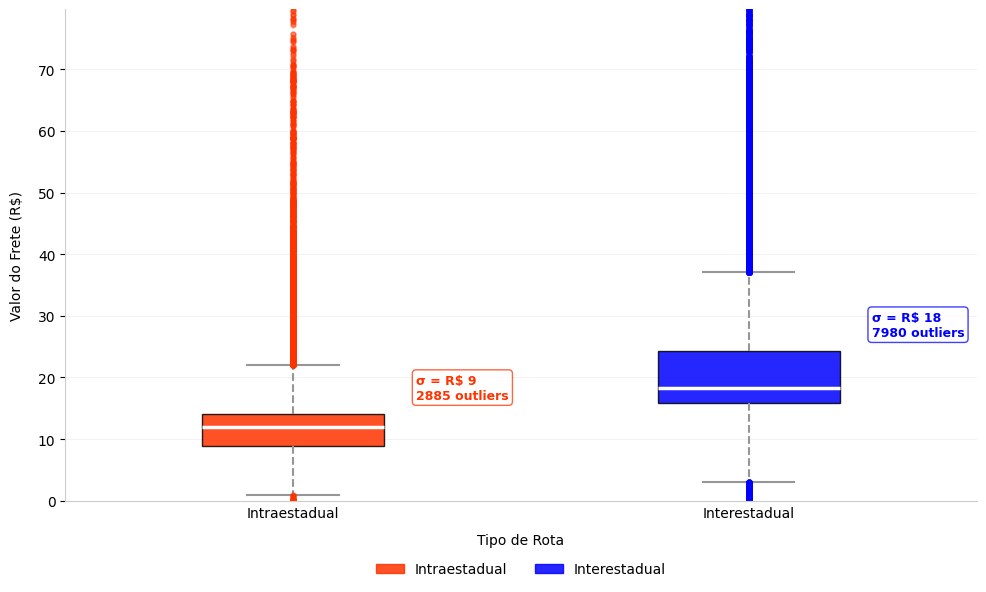

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

# ── Paleta e fonte ──────────────────────────────────────────────
COR_INTRA    = '#FF3300'
COR_INTER    = '#0000FF'
COR_GRID     = '#E7E6E6'
COR_SPINE    = '#CCCCCC'
FONTE        = 'Arial'
FONTE_SIZE   = 10

ordem = ['Intraestadual', 'Interestadual']
cores = [COR_INTRA, COR_INTER]

dados_plot = [
    produtos_final.loc[produtos_final['tipo_rota'] == cat, 'valor_frete'].dropna().values
    for cat in ordem
]

# ── Stats ────────────────────────────────────────────────────────
stats = []
for dados in dados_plot:
    q1, q3 = np.percentile(dados, [25, 75])
    iqr = q3 - q1
    stats.append({
        'std':        np.std(dados),
        'q3':         q3,
        'n_outliers': np.sum((dados < q1 - 1.5*iqr) | (dados > q3 + 1.5*iqr))
    })

# ── Figura ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bp = ax.boxplot(
    dados_plot,
    patch_artist=True,
    widths=0.40,
    medianprops=dict(color='white',     linewidth=2.5),
    whiskerprops=dict(color='#969696',   linewidth=1.5, linestyle='--'),
    capprops=dict(color='#969696',       linewidth=1.5),
    flierprops=dict(marker='o', markersize=3.5, linestyle='none', alpha=0.35),
    showfliers=True
)

for patch, cor in zip(bp['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.85)

for flier, cor in zip(bp['fliers'], cores):
    flier.set_markerfacecolor(cor)
    flier.set_markeredgecolor(cor)

# ── Anotações σ ──────────────────────────────────────────────────
for i, (s, cor) in enumerate(zip(stats, cores), start=1):
    ax.annotate(
        f"σ = R$ {s['std']:,.0f}\n{s['n_outliers']} outliers",
        xy=(i, s['q3']),
        xytext=(i + 0.27, s['q3'] + 2),
        fontsize=FONTE_SIZE - 1,
        fontfamily=FONTE,
        color=cor,
        fontweight='bold',
        va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=cor, alpha=0.75, linewidth=1)
    )

# ── Eixo Y limitado (percentil 95 × 1.5) ─────────────────────────
y_max = max(np.percentile(d, 95) for d in dados_plot) * 1.5
ax.set_ylim(bottom=0, top=y_max)

# ── Grid cinza claro, sem spines pesadas ─────────────────────────
ax.yaxis.grid(True, color=COR_GRID, linewidth=0.7, linestyle='-', alpha=0.5)
ax.set_axisbelow(True)
ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_edgecolor(COR_SPINE)
    spine.set_linewidth(0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Ticks e labels ───────────────────────────────────────────────
ax.set_xticks([1, 2])
ax.set_xticklabels(ordem, fontsize=FONTE_SIZE, fontfamily=FONTE, color='black')
ax.tick_params(axis='y', labelsize=FONTE_SIZE, colors='black')
ax.tick_params(axis='x', colors='black', length=0)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'.replace(',', '.')
))

# ── Títulos ──────────────────────────────────────────────────────
ax.set_ylabel('Valor do Frete (R$)', fontsize=FONTE_SIZE, fontfamily=FONTE,
              color='black', labelpad=10)
ax.set_xlabel('Tipo de Rota', fontsize=FONTE_SIZE, fontfamily=FONTE,
              color='black', labelpad=10)
# ── Legenda ──────────────────────────────────────────────────────
patches = [mpatches.Patch(color=cor, label=cat, alpha=0.85)
           for cat, cor in zip(ordem, cores)]
leg = ax.legend(handles=patches,
                loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3,
                fontsize=FONTE_SIZE,
                framealpha=0.1, edgecolor='white',
                labelcolor='black', facecolor='white')
for text in leg.get_texts():
    text.set_fontfamily(FONTE)

plt.tight_layout()
plt.show()